# Applied Exercise 13 - Weekly Stock Market Data

#### Objective of this exercise is to compare several classification techniques for predicting the weekly market direction using historical lag returns and trading volume.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data

import statsmodels.api as sm

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
Weekly = load_data("Weekly")

print(Weekly.head())
print(Weekly.info())
print(Weekly.describe())

   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), fl

            Year      Lag1      Lag2      Lag3      Lag4      Lag5    Volume  \
Year    1.000000 -0.032289 -0.033390 -0.030006 -0.031128 -0.030519  0.841942   
Lag1   -0.032289  1.000000 -0.074853  0.058636 -0.071274 -0.008183 -0.064951   
Lag2   -0.033390 -0.074853  1.000000 -0.075721  0.058382 -0.072499 -0.085513   
Lag3   -0.030006  0.058636 -0.075721  1.000000 -0.075396  0.060657 -0.069288   
Lag4   -0.031128 -0.071274  0.058382 -0.075396  1.000000 -0.075675 -0.061075   
Lag5   -0.030519 -0.008183 -0.072499  0.060657 -0.075675  1.000000 -0.058517   
Volume  0.841942 -0.064951 -0.085513 -0.069288 -0.061075 -0.058517  1.000000   
Today  -0.032460 -0.075032  0.059167 -0.071244 -0.007826  0.011013 -0.033078   

           Today  
Year   -0.032460  
Lag1   -0.075032  
Lag2    0.059167  
Lag3   -0.071244  
Lag4   -0.007826  
Lag5    0.011013  
Volume -0.033078  
Today   1.000000  


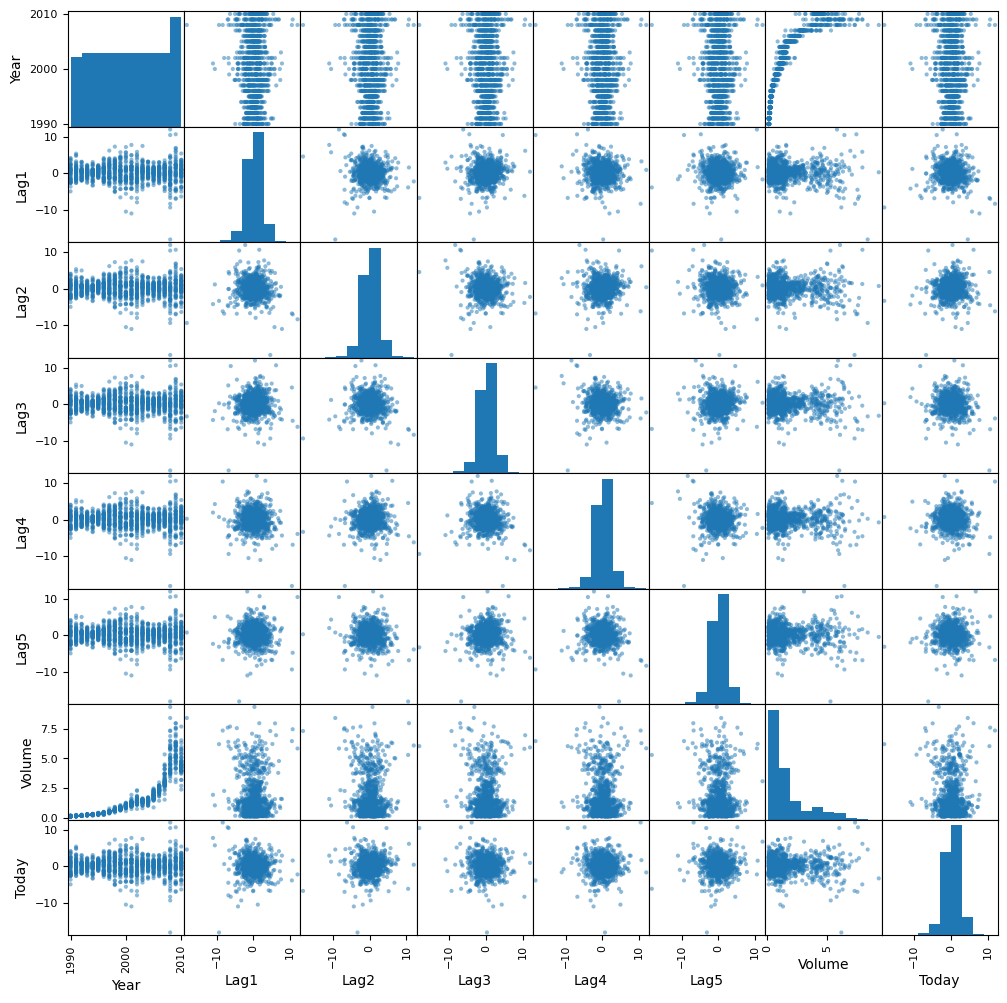

In [6]:
print(Weekly.corr(numeric_only=True))

pd.plotting.scatter_matrix(
    Weekly,
    figsize=(12,12)
)

plt.show()

- Volume has a very strong positive correlation with Year (0.84), indicating trading volume increased substantially over time.
- The lag variables have only weak correlations with each other.
- Today's return has almost zero correlation with every lag variable.
- No obvious linear relationship is visible from the correlation matrix.

In [7]:
X = Weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X = sm.add_constant(X)

y = (Weekly["Direction"] == "Up").astype(int)

log_model = sm.Logit(y, X).fit()

print(log_model.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                0.006580
Time:                        01:25:51   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

- The only significant predictor is Lag 2 wit p=0.03.
- The full model has a very weak predictive power (pseduo - R2 = 0.0065)

In [8]:
prob = log_model.predict(X)
pred = np.where(prob > 0.5, 1, 0)
cm = confusion_matrix(y, pred)
print(cm)

print("Accuracy =", accuracy_score(y, pred))

[[ 54 430]
 [ 48 557]]
Accuracy = 0.5610651974288338


The model predicts "Up" much more often than "Down". It has poor sensitivity for Down markets, but does reasonably well predicting Up markets.

In [9]:
train = Weekly["Year"] < 2009
test = Weekly["Year"] >= 2009

X_train = Weekly.loc[train, ["Lag2"]]
X_test = Weekly.loc[test, ["Lag2"]]

y_train = Weekly.loc[train, "Direction"]
y_test = Weekly.loc[test, "Direction"]

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

log_model = sm.Logit(
    (y_train=="Up").astype(int),
    X_train_sm
).fit()

prob = log_model.predict(X_test_sm)
pred = np.where(prob > 0.5, "Up", "Down")

print(confusion_matrix(y_test,pred))
print("Accuracy =",accuracy_score(y_test,pred))

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
[[ 9 34]
 [ 5 56]]
Accuracy = 0.625


The models performs better than using all predictors which shows more predictors do not necessarily improve test performance.

In [10]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train,y_train)
pred = lda.predict(X_test)

print(confusion_matrix(y_test,pred))
print("Accuracy =",accuracy_score(y_test,pred))

[[ 9 34]
 [ 5 56]]
Accuracy = 0.625


In [13]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train,y_train)
pred = qda.predict(X_test)

print(confusion_matrix(y_test,pred))
print("Accuracy =",accuracy_score(y_test,pred))

[[ 0 43]
 [ 0 61]]
Accuracy = 0.5865384615384616


QDA performs worse than LDA showing the relationships may not be necessarily quadratic.

In [11]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print(confusion_matrix(y_test,pred))
print("Accuracy =",accuracy_score(y_test,pred))

[[22 21]
 [31 30]]
Accuracy = 0.5


K = 1 memorizes the training data. Because stock returns are extremely noisy, the nearest neighbour is often not informative, resulting in random performance. This is a classic example of high variance, low bias / overfitting.

In [12]:
nb = GaussianNB()
nb.fit(X_train,y_train)
pred = nb.predict(X_test)

print(confusion_matrix(y_test,pred))
print("Accuracy =",accuracy_score(y_test,pred))

[[ 0 43]
 [ 0 61]]
Accuracy = 0.5865384615384616


- Naive Bayes predicts every observation as "Up". Since about 59% of the test observations are Up, it achieves nearly 59% accuracy simply by always choosing the majority class. This illustrates why accuracy alone can be misleading on imbalanced datasets.
- Therefore, Logistic Regression and LDA using only Lag2 provide the best predictive performance on the held-out data, with both achieving an accuracy of approximately 62.5%. These models outperform the more complex methods, suggesting that a simple linear decision boundary is sufficient for this dataset.

In [15]:
print("="*70)
print("Model Comparison")
print("="*70)

train = Weekly["Year"] < 2009
test = Weekly["Year"] >= 2009
results = []

# -------------------------------------------------------
# Logistic Regression
# -------------------------------------------------------

log_models = [
    ["Lag2"],
    ["Lag1","Lag2"],
    ["Lag2","Volume"],
    ["Lag1","Lag2","Volume"]
]

for cols in log_models:
    X_train = sm.add_constant(Weekly.loc[train, cols])
    X_test = sm.add_constant(Weekly.loc[test, cols])

    y_train = (Weekly.loc[train,"Direction"]=="Up").astype(int)
    y_test = Weekly.loc[test,"Direction"]

    model = sm.Logit(y_train,X_train).fit(disp=False)
    prob = model.predict(X_test)
    pred = np.where(prob>0.5,"Up","Down")
    acc = accuracy_score(y_test,pred)
    results.append([
        "Logistic",
        ",".join(cols),
        "-",
        acc
    ])

# -------------------------------------------------------
# LDA
# -------------------------------------------------------

cols=["Lag1","Lag2"]

X_train=Weekly.loc[train,cols]
X_test=Weekly.loc[test,cols]

y_train=Weekly.loc[train,"Direction"]
y_test=Weekly.loc[test,"Direction"]

lda=LinearDiscriminantAnalysis()
lda.fit(X_train,y_train)

pred=lda.predict(X_test)
results.append([
    "LDA",
    "Lag1,Lag2",
    "-",
    accuracy_score(y_test,pred)
])

# -------------------------------------------------------
# QDA
# -------------------------------------------------------

qda=QuadraticDiscriminantAnalysis()
qda.fit(X_train,y_train)
pred=qda.predict(X_test)
results.append([
    "QDA",
    "Lag1,Lag2",
    "-",
    accuracy_score(y_test,pred)
])

# -------------------------------------------------------
# Naive Bayes
# -------------------------------------------------------

nb=GaussianNB()
nb.fit(X_train,y_train)
pred=nb.predict(X_test)
results.append([
    "Naive Bayes",
    "Lag1,Lag2",
    "-",
    accuracy_score(y_test,pred)
])

# -------------------------------------------------------
# KNN
# -------------------------------------------------------

for k in [1,3,5,7,9,15]:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    pred=knn.predict(X_test)
    results.append([
        "KNN",
        "Lag1,Lag2",
        k,
        accuracy_score(y_test,pred)
    ])

results_df=pd.DataFrame(
    results,
    columns=["Method","Predictors","K","Accuracy"]
)

results_df=results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)
best=results_df.iloc[0]
print("\nBest Model")
print(best)

Model Comparison
         Method        Predictors   K  Accuracy
0      Logistic              Lag2   -  0.625000
1      Logistic         Lag1,Lag2   -  0.576923
4           LDA         Lag1,Lag2   -  0.576923
12          KNN         Lag1,Lag2  15  0.576923
5           QDA         Lag1,Lag2   -  0.557692
11          KNN         Lag1,Lag2   9  0.538462
2      Logistic       Lag2,Volume   -  0.538462
6   Naive Bayes         Lag1,Lag2   -  0.538462
3      Logistic  Lag1,Lag2,Volume   -  0.528846
10          KNN         Lag1,Lag2   7  0.528846
8           KNN         Lag1,Lag2   3  0.519231
9           KNN         Lag1,Lag2   5  0.490385
7           KNN         Lag1,Lag2   1  0.480769

Best Model
Method        Logistic
Predictors        Lag2
K                    -
Accuracy         0.625
Name: 0, dtype: object


Several combinations of predictors and classification methods were evaluated. Logistic Regression and LDA consistently produced the highest predictive accuracy. Including additional predictors such as Lag1 and Volume did not substantially improve performance over using Lag2 alone. QDA and KNN generally performed worse, suggesting that the relationship between lagged returns and market direction is weak and approximately linear.